# 🚢 Outlier Detection using the Percentile Method (Winsorization)

## 📌 Objective
In this notebook, we will learn how to detect and handle outliers using the **Percentile Method**, also known as the **Winsorization Technique**. We will apply this technique to the Titanic dataset and compare the data before and after treating outliers.

---

# 📖 What are Outliers?

Outliers are extreme observations that lie significantly away from the majority of the data. They can occur due to:
- Data entry errors
- Measurement errors
- Natural variation
- Rare events

Outliers can negatively impact machine learning models by:
- Distorting statistical measures like mean and standard deviation.
- Reducing model performance.
- Increasing prediction errors.
- Influencing algorithms that rely on distance calculations.

---

# 📊 What is the Percentile Method?

The Percentile Method detects outliers based on the distribution of the data.

Instead of using statistical measures like the IQR or Z-Score, it defines lower and upper boundaries using percentiles.

For example:
- Lower Boundary = 1st Percentile
- Upper Boundary = 99th Percentile

Any value outside these boundaries is considered an outlier.

---

# ✂️ What is Winsorization?

Winsorization is a technique used to **cap** extreme values rather than removing them.

Instead of deleting outliers:
- Values below the lower percentile are replaced with the lower percentile value.
- Values above the upper percentile are replaced with the upper percentile value.

This preserves all observations while reducing the impact of extreme values.

---

# 🎯 Why Winsorization?

Winsorization helps:
- Reduce the influence of extreme values.
- Preserve the size of the dataset.
- Improve model stability.
- Prevent information loss caused by deleting rows.

---

# ⚙️ Steps Involved

1. Load the dataset.
2. Select a numerical feature.
3. Calculate lower and upper percentile values.
4. Identify outliers.
5. Replace extreme values using Winsorization.
6. Compare the data before and after capping.
7. Visualize the results using boxplots and histograms.

---

# ✅ Advantages

- Simple to implement.
- Preserves all records.
- Reduces the impact of extreme values.
- Improves robustness of many machine learning algorithms.
- Useful when outliers are genuine observations rather than errors.

---

# ❌ Disadvantages

- Threshold selection (e.g., 1% and 99%) is subjective.
- Extreme values are modified, which may remove meaningful information.
- Not suitable if outliers represent important rare events.
- Can slightly distort the original distribution of the data.

---

# 🚢 Dataset

We will use the **Titanic Dataset**.

The numerical columns suitable for this experiment include:
- Age
- Fare
- SibSp
- Parch

Among these, **Fare** is commonly used because it contains several high-value outliers.

---

# 🛠 Libraries Required

- Pandas
- NumPy
- Matplotlib
- Seaborn

---

# 📈 Workflow

1. Import Libraries
2. Load Titanic Dataset
3. Explore Numerical Features
4. Visualize Outliers
5. Calculate Percentiles
6. Detect Outliers
7. Apply Winsorization
8. Compare Before vs After
9. Draw Conclusions

---

# 🎯 Expected Outcome

After completing this notebook, you will be able to:

- Understand what outliers are.
- Detect outliers using the Percentile Method.
- Apply Winsorization to cap extreme values.
- Visualize the effect of capping.
- Decide when Winsorization is a better choice than removing outliers.

---

# 📌 Interview Questions

1. What are outliers?
2. What is the Percentile Method?
3. What is Winsorization?
4. Why do we cap outliers instead of removing them?
5. When should Winsorization be preferred over trimming?
6. What is the difference between IQR and Percentile Method?
7. Can Winsorization improve model performance?
8. Which machine learning algorithms are sensitive to outliers?

---

In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df['Fare']

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


In [8]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


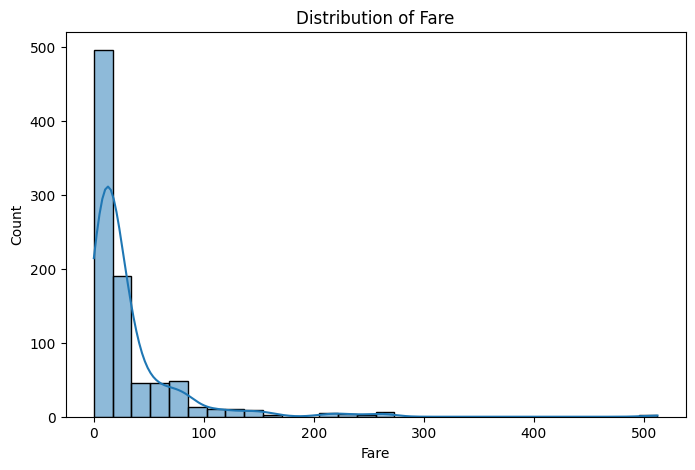

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.show()

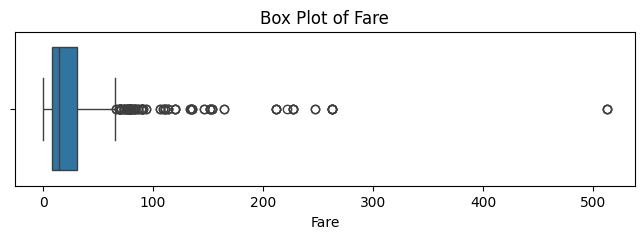

In [10]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['Fare'])
plt.title("Box Plot of Fare")
plt.show()

In [11]:
df['Fare'].skew()

np.float64(4.787316519674893)

In [12]:
lower_limit = df['Fare'].quantile(0.01)
upper_limit = df['Fare'].quantile(0.99)

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 0.0
Upper Limit: 249.00622000000035


In [13]:
df[(df['Fare'] < lower_limit) | (df['Fare'] > upper_limit)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [14]:
outliers = df[(df['Fare'] < lower_limit) | (df['Fare'] > upper_limit)]

print("Number of Outliers:", outliers.shape[0])

Number of Outliers: 9


In [15]:
print(outliers.shape)

(9, 12)


In [16]:
print("Lower Outliers:", (df['Fare'] < lower_limit).sum())

Lower Outliers: 0


In [17]:
print("Upper Outliers:", (df['Fare'] > upper_limit).sum())

Upper Outliers: 9


In [19]:
df_cap = df.copy()

In [20]:
df_cap['Fare'] = np.where(
    df_cap['Fare'] > upper_limit,
    upper_limit,
    np.where(
        df_cap['Fare'] < lower_limit,
        lower_limit,
        df_cap['Fare']
    )
)

In [21]:
df_cap['Fare'].describe()

,Fare
count,891.000000
mean,31.224767
std,42.524125
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,249.006220


In [22]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


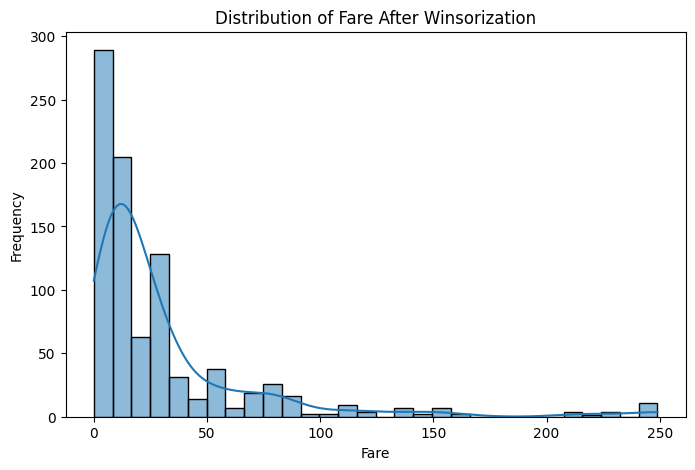

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df_cap['Fare'], bins=30, kde=True)

plt.title("Distribution of Fare After Winsorization")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

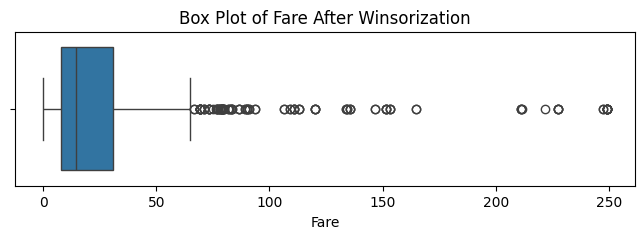

In [24]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df_cap['Fare'])

plt.title("Box Plot of Fare After Winsorization")

plt.show()

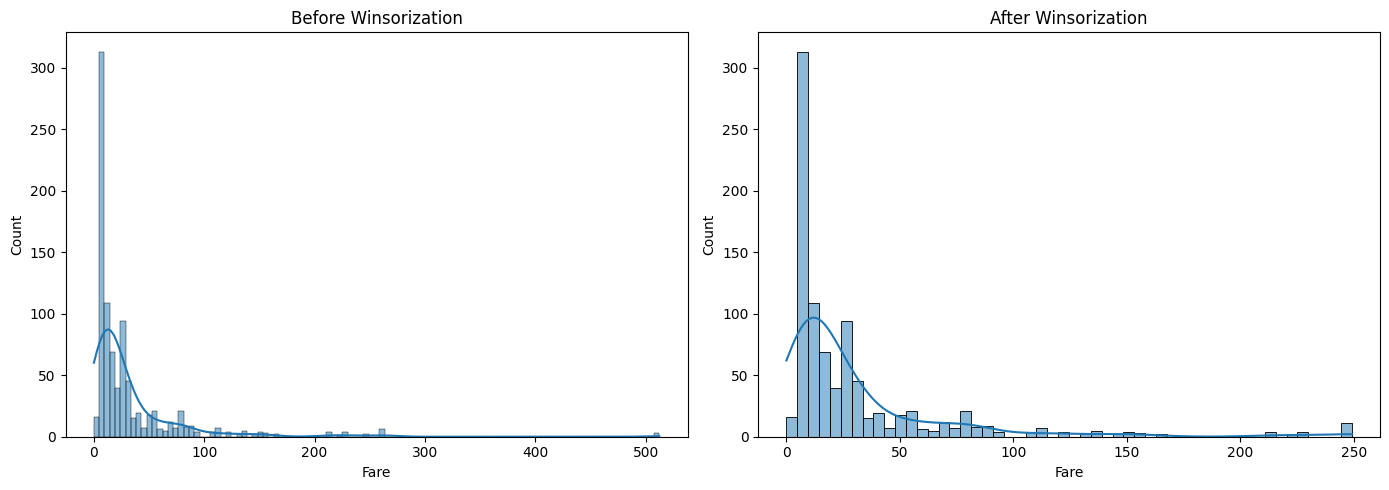

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Original Data
sns.histplot(df['Fare'], kde=True, ax=ax[0])
ax[0].set_title("Before Winsorization")

# Capped Data
sns.histplot(df_cap['Fare'], kde=True, ax=ax[1])
ax[1].set_title("After Winsorization")

plt.tight_layout()
plt.show()

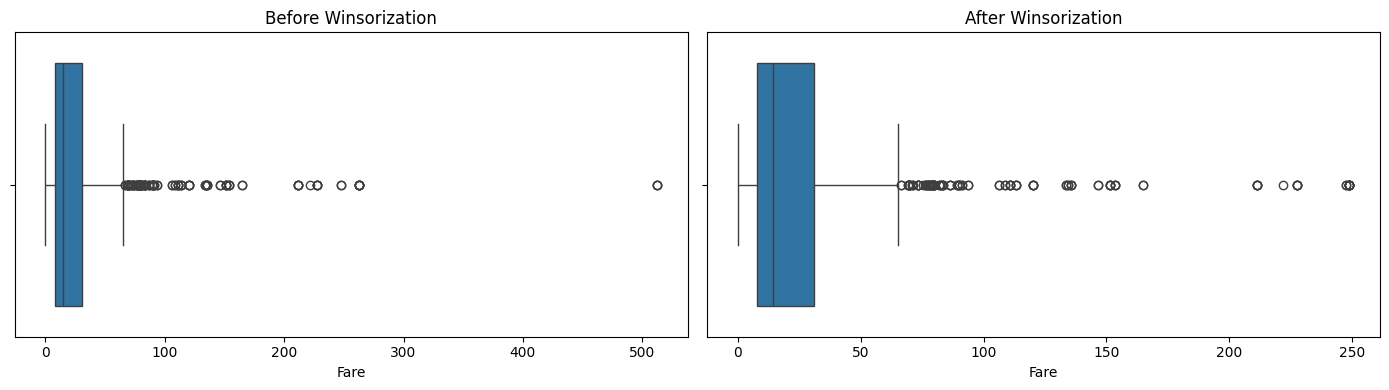

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))

sns.boxplot(x=df['Fare'], ax=ax[0])
ax[0].set_title("Before Winsorization")

sns.boxplot(x=df_cap['Fare'], ax=ax[1])
ax[1].set_title("After Winsorization")

plt.tight_layout()
plt.show()

In [27]:
print("Before Winsorization")
print(df['Fare'].describe())

print("\n" + "="*50 + "\n")

print("After Winsorization")
print(df_cap['Fare'].describe())

Before Winsorization
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


After Winsorization
count    891.000000
mean      31.224767
std       42.524125
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      249.006220
Name: Fare, dtype: float64
